# ✈️ Travel & Wellness Tourism — Complete EDA + ML Pipeline
> **Dataset:** Travel Product Purchase Prediction  
> **Target:** `ProdTaken` — whether a customer purchased a travel product  
> **Author:** Data Science Team  

---


In [1]:
# ── Core Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── ML ──
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              accuracy_score, f1_score, precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import joblib
import os

# ── Plot Style ──
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (10, 5)})
PAL = ['#00D4FF','#7B61FF','#FF3CAC','#FFB547','#00E5A0','#4ECDC4','#FF6B6B']

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


## 1. Data Loading & Basic Inspection

In [2]:
df = pd.read_csv('travel_dataset.csv')

print("=" * 65)
print(f"📐 Shape        : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print("=" * 65)
print("\n📋 Column dtypes:")
print(df.dtypes.to_string())
print("\n📊 First 5 rows:")
df.head()


📐 Shape        : 4,888 rows  ×  20 columns

📋 Column dtypes:
CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64

📊 First 5 rows:


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## 2. Data Quality — Missing Values, Duplicates, Cardinality

In [3]:
print("=" * 65)
print("❌ MISSING VALUES")
print("=" * 65)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
print(miss_df[miss_df['Count'] > 0].sort_values('Count', ascending=False).to_string())

print(f"\n🔁 Duplicate rows : {df.duplicated().sum()}")

print("\n📦 Unique value counts per column:")
for col in df.columns:
    print(f"  {col:<30} {df[col].nunique():>4} unique | dtype: {df[col].dtype}")


❌ MISSING VALUES
                          Count  Pct (%)
DurationOfPitch             251     5.14
MonthlyIncome               233     4.77
Age                         226     4.62
NumberOfTrips               140     2.86
NumberOfChildrenVisiting     66     1.35
NumberOfFollowups            45     0.92
PreferredPropertyStar        26     0.53
TypeofContact                25     0.51

🔁 Duplicate rows : 0

📦 Unique value counts per column:
  CustomerID                     4888 unique | dtype: int64
  ProdTaken                         2 unique | dtype: int64
  Age                              44 unique | dtype: float64
  TypeofContact                     2 unique | dtype: object
  CityTier                          3 unique | dtype: int64
  DurationOfPitch                  34 unique | dtype: float64
  Occupation                        4 unique | dtype: object
  Gender                            3 unique | dtype: object
  NumberOfPersonVisiting            5 unique | dtype: int64
  NumberOf

## 3. Descriptive Statistics

In [4]:
print("📊 Numerical Summary:")
df.describe().round(2)


📊 Numerical Summary:


,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.00,4888.00,4662.00,4888.00,4637.00,4888.00,4843.00,4862.00,4748.00,4888.00,4888.00,4888.00,4822.00,4655.00
mean,202443.50,0.19,37.62,1.65,15.49,2.91,3.71,3.58,3.24,0.29,3.08,0.62,1.19,23619.85
std,1411.19,0.39,9.32,0.92,8.52,0.72,1.00,0.80,1.85,0.45,1.37,0.49,0.86,5380.70
min,200000.00,0.00,18.00,1.00,5.00,1.00,1.00,3.00,1.00,0.00,1.00,0.00,0.00,1000.00
25%,201221.75,0.00,31.00,1.00,9.00,2.00,3.00,3.00,2.00,0.00,2.00,0.00,1.00,20346.00
50%,202443.50,0.00,36.00,1.00,13.00,3.00,4.00,3.00,3.00,0.00,3.00,1.00,1.00,22347.00
75%,203665.25,0.00,44.00,3.00,20.00,3.00,4.00,4.00,4.00,1.00,4.00,1.00,2.00,25571.00
max,204887.00,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,5.00,1.00,3.00,98678.00


In [5]:
print("🏷 Categorical Summary:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\n── {col} ──")
    print(df[col].value_counts(dropna=False).to_string())


🏷 Categorical Summary:

── TypeofContact ──
TypeofContact
Self Enquiry       3444
Company Invited    1419
NaN                  25

── Occupation ──
Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2

── Gender ──
Gender
Male       2916
Female     1817
Fe Male     155

── ProductPitched ──
ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230

── MaritalStatus ──
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682

── Designation ──
Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230


## 4. Target Variable Analysis — `ProdTaken`

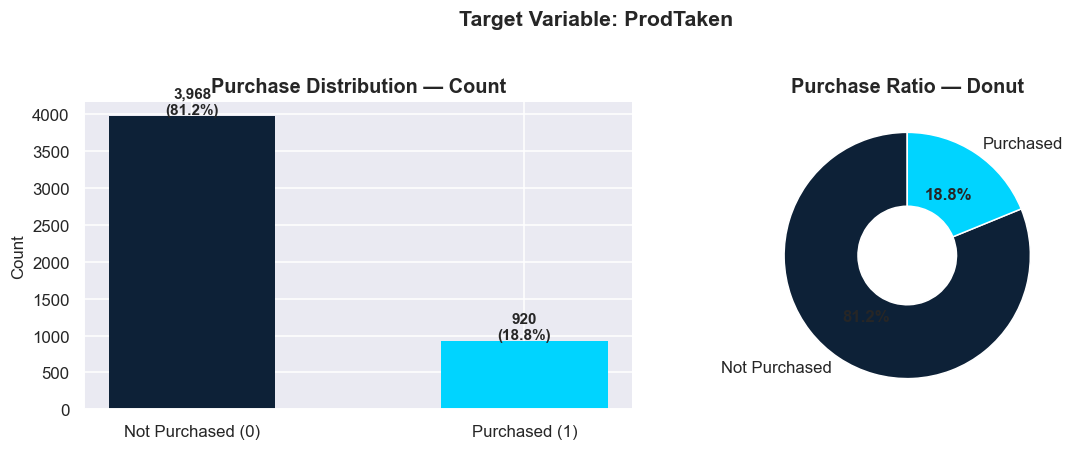

⚠️  Class imbalance ratio: 4.31 : 1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
vc = df['ProdTaken'].value_counts()
bars = axes[0].bar(['Not Purchased (0)', 'Purchased (1)'], vc.values,
                   color=['#0D2137','#00D4FF'], edgecolor='none', width=0.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Purchase Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

# Pie
wedges, texts, autotexts = axes[1].pie(
    vc.values, labels=['Not Purchased','Purchased'],
    autopct='%1.1f%%', startangle=90,
    colors=['#0D2137','#00D4FF'], wedgeprops=dict(width=0.6),
    textprops=dict(fontsize=11))
for at in autotexts: at.set_fontweight('bold')
axes[1].set_title('Purchase Ratio — Donut', fontweight='bold')

plt.suptitle('Target Variable: ProdTaken', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_target.png', dpi=110, bbox_inches='tight')
plt.show()

print(f"⚠️  Class imbalance ratio: {vc[0]/vc[1]:.2f} : 1")


## 5. Data Cleaning

In [7]:
dfc = df.copy()

# Fix known typo in Gender
dfc['Gender'] = dfc['Gender'].replace('Fe Male', 'Female')
print("✅ Fixed 'Fe Male' → 'Female'")
print("   Gender counts:", dfc['Gender'].value_counts().to_dict())

# Impute missing values
num_cols  = dfc.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols  = dfc.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    if dfc[col].isnull().sum() > 0:
        median_val = dfc[col].median()
        dfc[col].fillna(median_val, inplace=True)
        print(f"✅ Imputed {col:<30} with median = {median_val:.2f}")

for col in cat_cols:
    if dfc[col].isnull().sum() > 0:
        mode_val = dfc[col].mode()[0]
        dfc[col].fillna(mode_val, inplace=True)
        print(f"✅ Imputed {col:<30} with mode  = {mode_val}")

print(f"\n🧹 Remaining missing values: {dfc.isnull().sum().sum()}")


✅ Fixed 'Fe Male' → 'Female'
   Gender counts: {'Male': 2916, 'Female': 1972}
✅ Imputed Age                            with median = 36.00
✅ Imputed DurationOfPitch                with median = 13.00
✅ Imputed NumberOfFollowups              with median = 4.00
✅ Imputed PreferredPropertyStar          with median = 3.00
✅ Imputed NumberOfTrips                  with median = 3.00
✅ Imputed NumberOfChildrenVisiting       with median = 1.00
✅ Imputed MonthlyIncome                  with median = 22347.00
✅ Imputed TypeofContact                  with mode  = Self Enquiry

🧹 Remaining missing values: 0


## 6. Outlier Detection & Treatment (IQR Method)

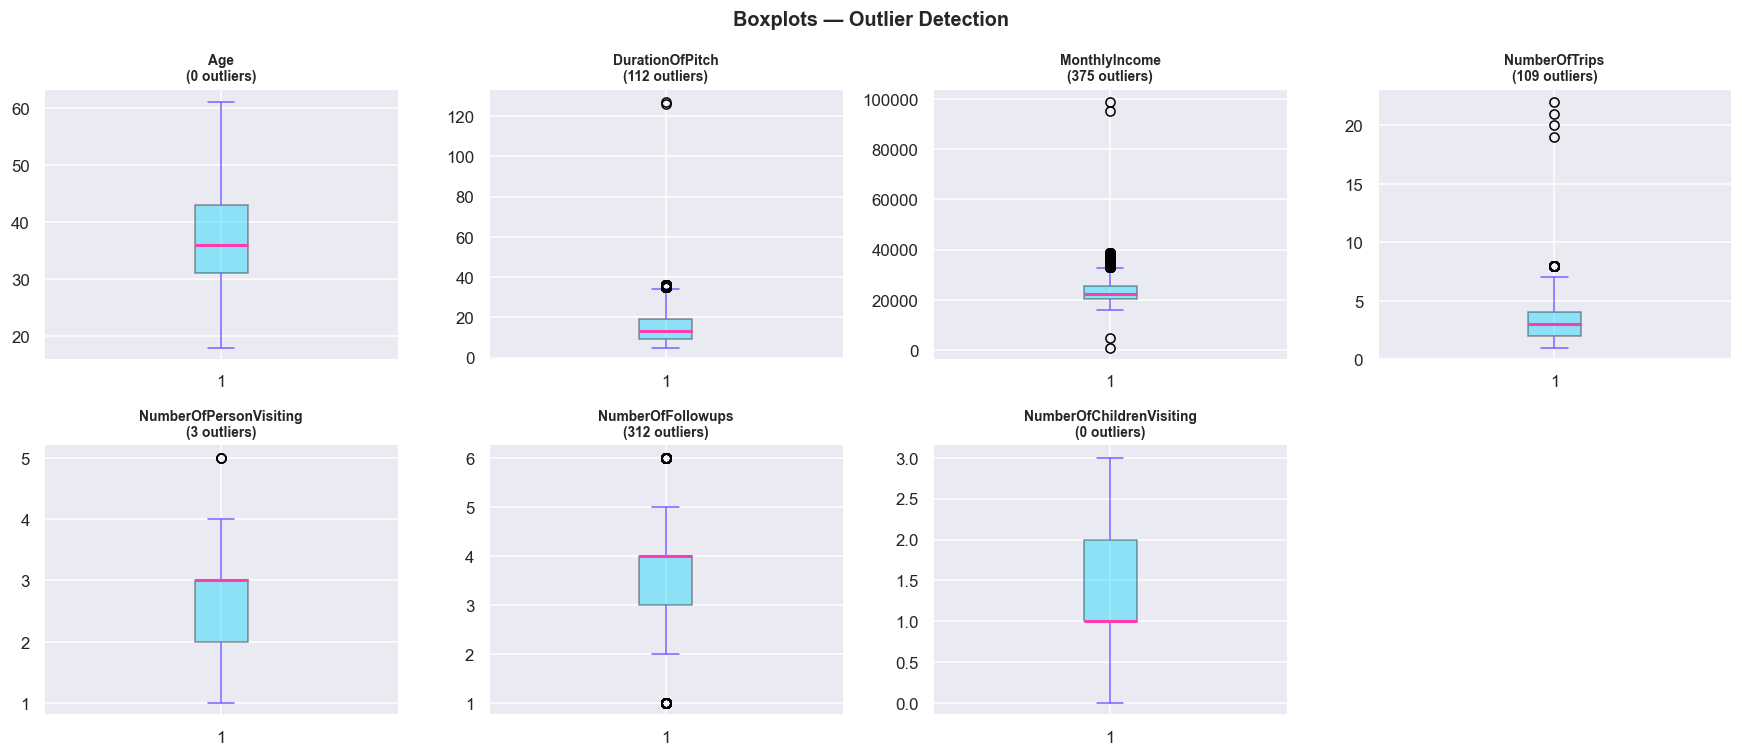

✅ Outliers capped using IQR method
   Capped columns: ['Age', 'DurationOfPitch', 'MonthlyIncome', 'NumberOfTrips', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'NumberOfChildrenVisiting']


In [8]:
outlier_num = ['Age','DurationOfPitch','MonthlyIncome','NumberOfTrips',
               'NumberOfPersonVisiting','NumberOfFollowups','NumberOfChildrenVisiting']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

outlier_counts = {}
for i, col in enumerate(outlier_num):
    Q1, Q3 = dfc[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((dfc[col] < lb) | (dfc[col] > ub)).sum()
    outlier_counts[col] = n_out

    axes[i].boxplot(dfc[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#00D4FF', alpha=0.4),
                    medianprops=dict(color='#FF3CAC', linewidth=2),
                    whiskerprops=dict(color='#7B61FF'),
                    capprops=dict(color='#7B61FF'))
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontsize=9, fontweight='bold')
    axes[i].spines[['top','right']].set_visible(False)

axes[-1].axis('off')
plt.suptitle('Boxplots — Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outliers.png', dpi=110, bbox_inches='tight')
plt.show()

# Cap outliers
for col in outlier_num:
    Q1, Q3 = dfc[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    dfc[col] = dfc[col].clip(lower=lb, upper=ub)

print("✅ Outliers capped using IQR method")
print("   Capped columns:", outlier_num)


## 7. Univariate Analysis — Numerical Features

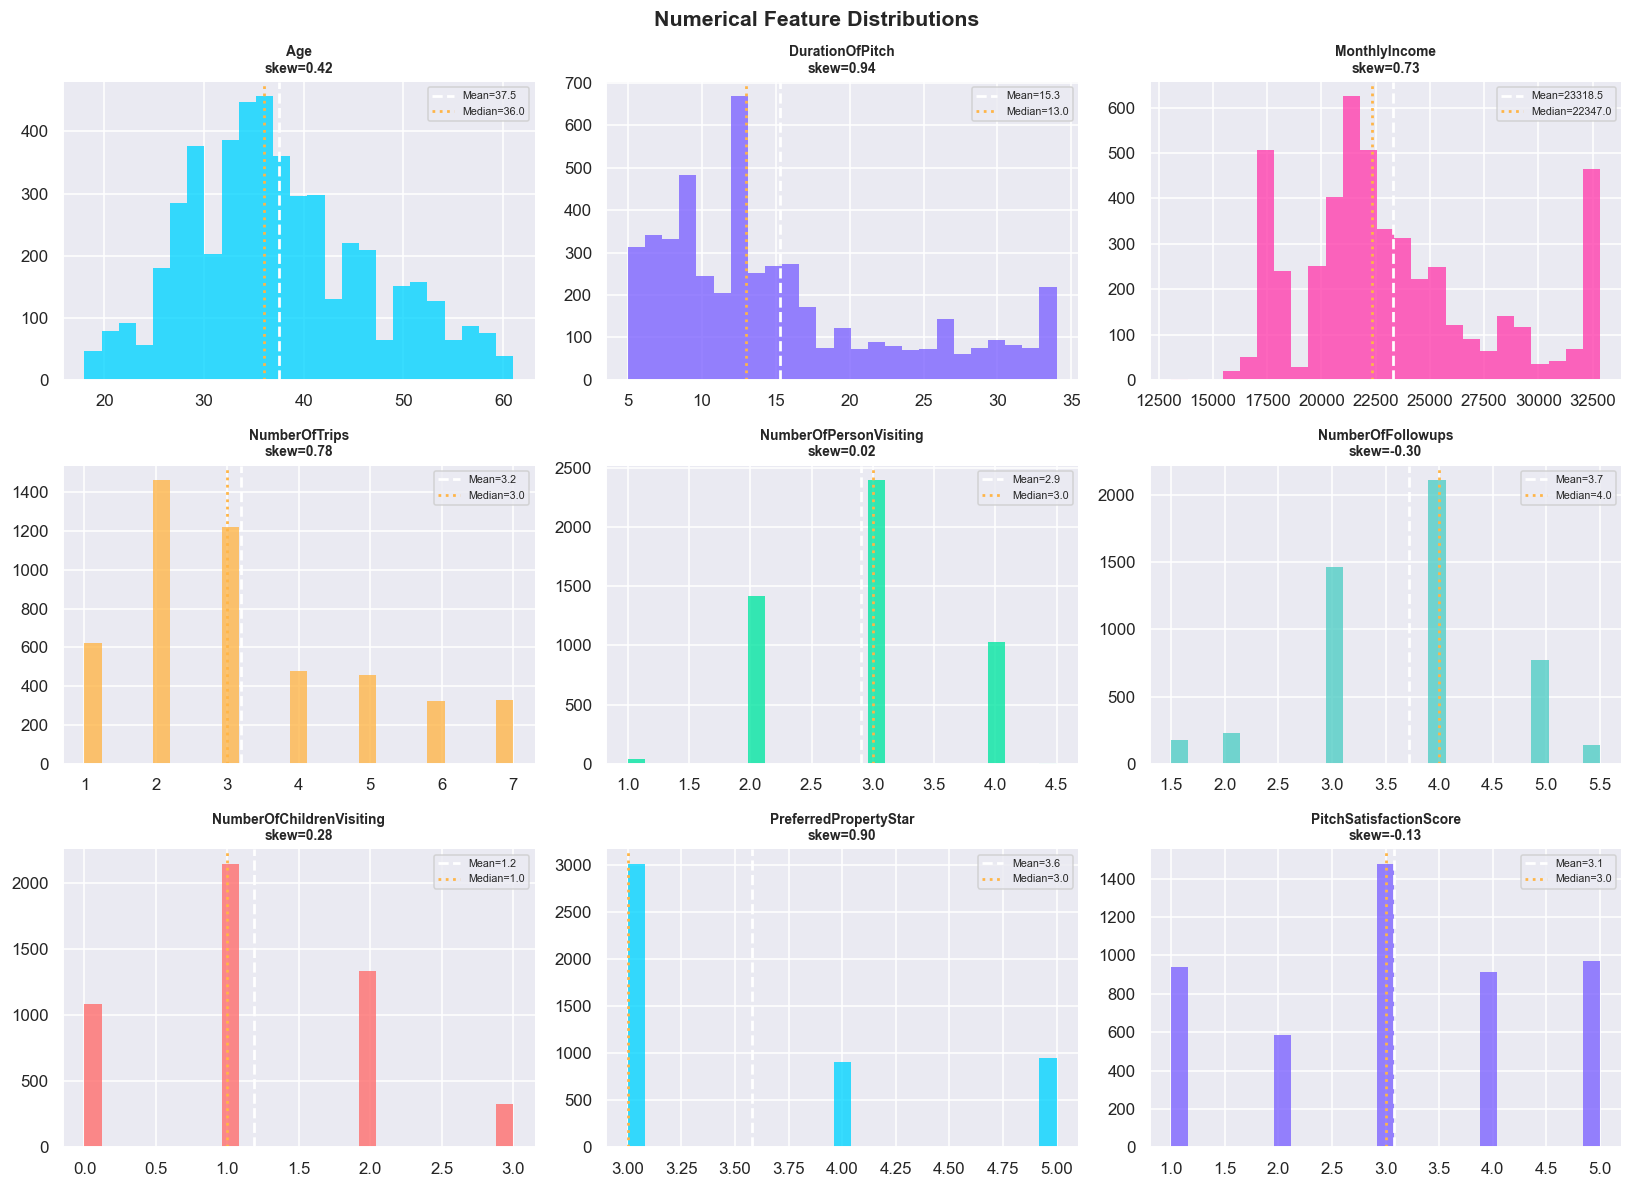

In [9]:
num_feat = ['Age','DurationOfPitch','MonthlyIncome','NumberOfTrips',
            'NumberOfPersonVisiting','NumberOfFollowups','NumberOfChildrenVisiting',
            'PreferredPropertyStar','PitchSatisfactionScore']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_feat):
    data = dfc[col].dropna()
    axes[i].hist(data, bins=25, color=PAL[i % len(PAL)], edgecolor='none', alpha=0.78)
    axes[i].axvline(data.mean(),   color='white', linewidth=1.8, linestyle='--', label=f'Mean={data.mean():.1f}')
    axes[i].axvline(data.median(), color='#FFB547', linewidth=1.8, linestyle=':', label=f'Median={data.median():.1f}')
    axes[i].set_title(f'{col}\nskew={data.skew():.2f}', fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_univariate_num.png', dpi=110, bbox_inches='tight')
plt.show()


## 8. Univariate Analysis — Categorical Features

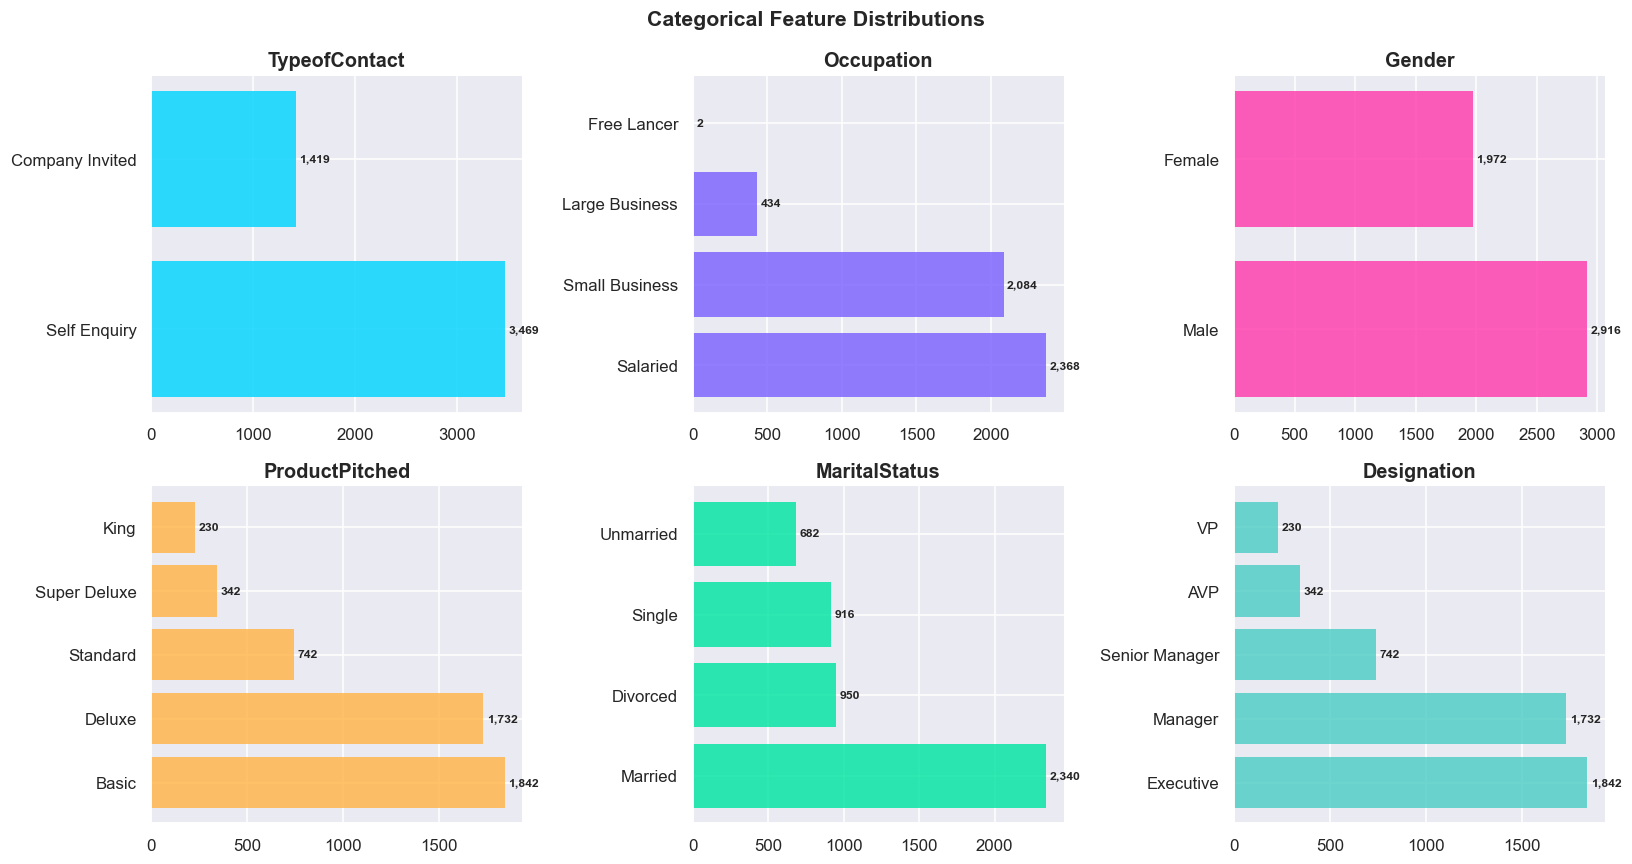

In [10]:
cat_feat = ['TypeofContact','Occupation','Gender','ProductPitched','MaritalStatus','Designation']
colors = ['#00D4FF','#7B61FF','#FF3CAC','#FFB547','#00E5A0','#4ECDC4']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_feat):
    vc = dfc[col].value_counts()
    bars = axes[i].barh(vc.index.astype(str), vc.values,
                        color=colors[i], edgecolor='none', alpha=0.82)
    for bar, val in zip(bars, vc.values):
        axes[i].text(bar.get_width() + vc.values.max()*0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8, fontweight='bold')
    axes[i].set_title(col, fontweight='bold')
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_univariate_cat.png', dpi=110, bbox_inches='tight')
plt.show()


## 9. Bivariate Analysis — Features vs Target

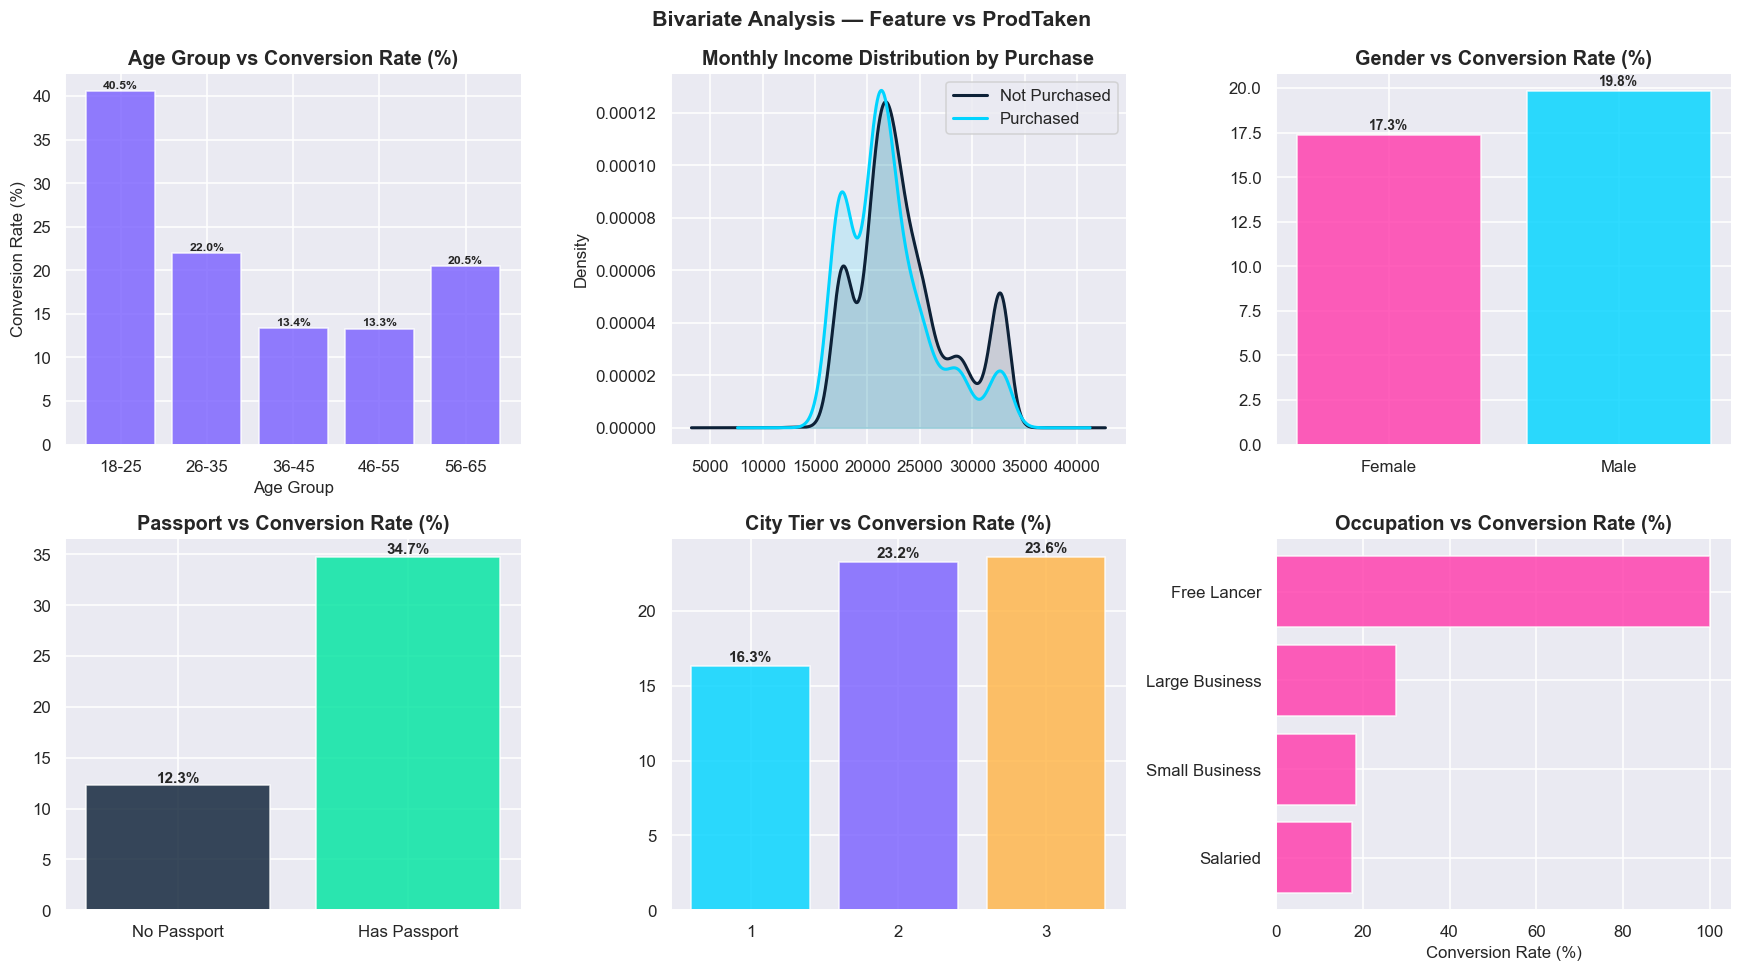

In [11]:
# Age Group feature
dfc['AgeGroup'] = pd.cut(dfc['Age'], bins=[18,25,35,45,55,65,100],
                          labels=['18-25','26-35','36-45','46-55','56-65','65+'])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. Age vs Conversion
ag = dfc.groupby('AgeGroup', observed=True)['ProdTaken'].mean().reset_index()
ag['CR'] = ag['ProdTaken'] * 100
axes[0].bar(ag['AgeGroup'].astype(str), ag['CR'], color='#7B61FF', alpha=0.82)
axes[0].set_title('Age Group vs Conversion Rate (%)', fontweight='bold')
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Conversion Rate (%)')
for bar, val in zip(axes[0].patches, ag['CR']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',
                 ha='center', fontsize=8, fontweight='bold')

# 2. Income Distribution by Target
dfc[dfc['ProdTaken']==0]['MonthlyIncome'].plot.kde(ax=axes[1], color='#0D2137', linewidth=2, label='Not Purchased')
dfc[dfc['ProdTaken']==1]['MonthlyIncome'].plot.kde(ax=axes[1], color='#00D4FF', linewidth=2, label='Purchased')
axes[1].fill_between(axes[1].lines[0].get_xdata(), axes[1].lines[0].get_ydata(), alpha=0.15, color='#0D2137')
axes[1].fill_between(axes[1].lines[1].get_xdata(), axes[1].lines[1].get_ydata(), alpha=0.15, color='#00D4FF')
axes[1].set_title('Monthly Income Distribution by Purchase', fontweight='bold')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

# 3. Gender vs Conversion
gc = dfc.groupby('Gender')['ProdTaken'].mean().reset_index()
gc['CR'] = gc['ProdTaken']*100
axes[2].bar(gc['Gender'], gc['CR'], color=['#FF3CAC','#00D4FF','#FFB547'], alpha=0.82)
axes[2].set_title('Gender vs Conversion Rate (%)', fontweight='bold')
for bar, val in zip(axes[2].patches, gc['CR']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# 4. Passport vs Conversion
pc = dfc.groupby('Passport')['ProdTaken'].mean() * 100
axes[3].bar(['No Passport','Has Passport'], pc.values, color=['#0D2137','#00E5A0'], alpha=0.82)
axes[3].set_title('Passport vs Conversion Rate (%)', fontweight='bold')
for bar, val in zip(axes[3].patches, pc.values):
    axes[3].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

# 5. City Tier vs Conversion
ct = dfc.groupby('CityTier')['ProdTaken'].mean().reset_index()
ct['CR'] = ct['ProdTaken']*100; ct['CityTier'] = ct['CityTier'].astype(str)
axes[4].bar(ct['CityTier'], ct['CR'], color=['#00D4FF','#7B61FF','#FFB547'], alpha=0.82)
axes[4].set_title('City Tier vs Conversion Rate (%)', fontweight='bold')
for bar, val in zip(axes[4].patches, ct['CR']):
    axes[4].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

# 6. Occupation vs Conversion
oc = dfc.groupby('Occupation')['ProdTaken'].mean().sort_values()
axes[5].barh(oc.index, oc.values*100, color='#FF3CAC', alpha=0.82)
axes[5].set_title('Occupation vs Conversion Rate (%)', fontweight='bold')
axes[5].set_xlabel('Conversion Rate (%)')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Bivariate Analysis — Feature vs ProdTaken', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bivariate.png', dpi=110, bbox_inches='tight')
plt.show()


## 10. Correlation Matrix

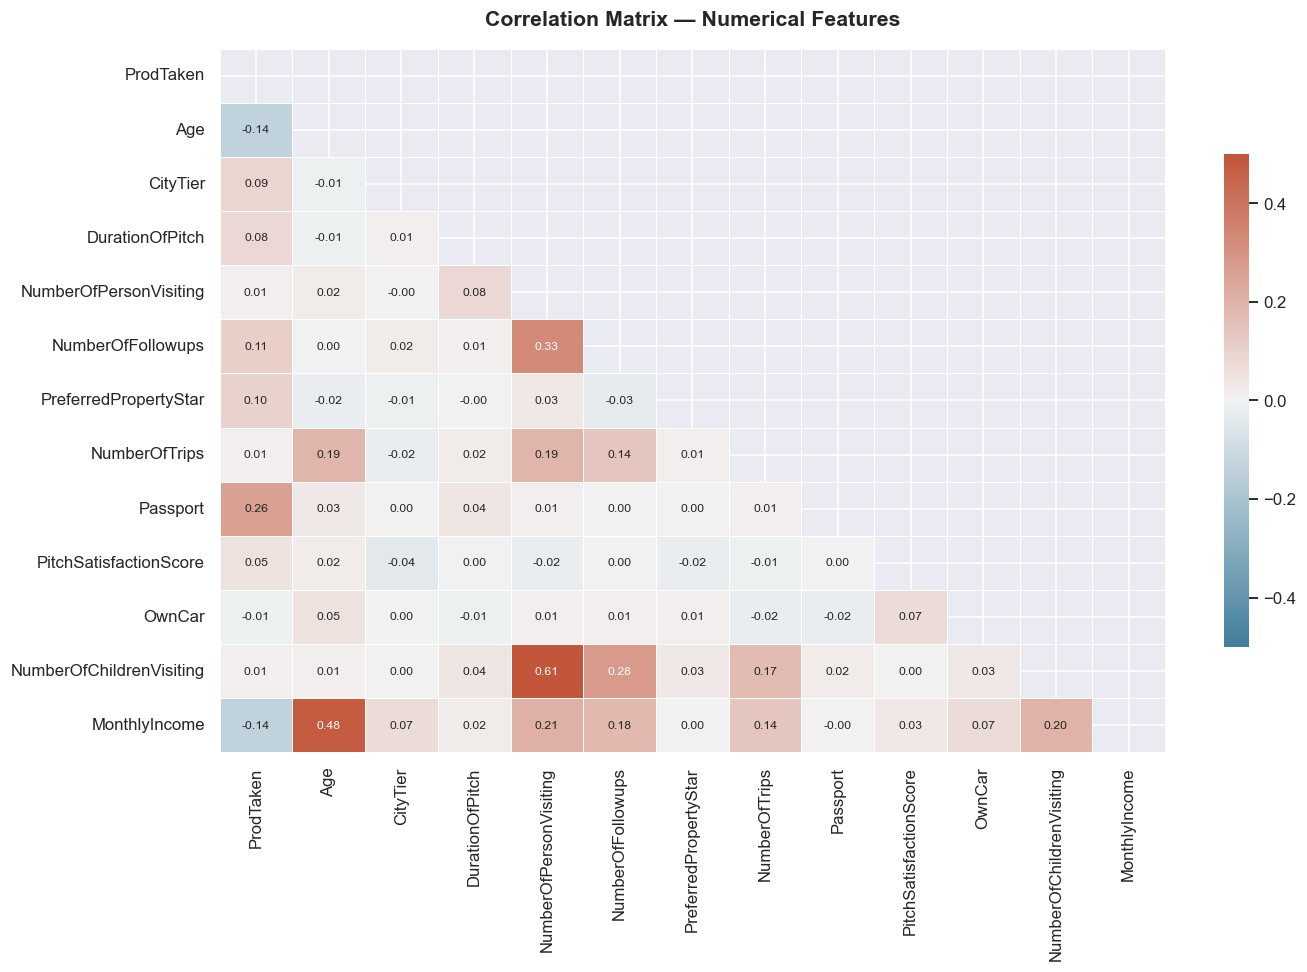


🎯 Top correlations with ProdTaken:
Passport                    0.26
Age                        -0.14
MonthlyIncome              -0.14
NumberOfFollowups           0.11
PreferredPropertyStar       0.10
CityTier                    0.09
DurationOfPitch             0.08
PitchSatisfactionScore      0.05
NumberOfPersonVisiting      0.01
NumberOfTrips               0.01
OwnCar                     -0.01
NumberOfChildrenVisiting    0.01


In [12]:
num_df = dfc.select_dtypes(include=np.number).drop(columns=['CustomerID'])
corr = num_df.corr().round(2)

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.5, vmin=-0.5, center=0,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax, cbar_kws={'shrink':.7},
            annot_kws={'size':8})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=110, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr['ProdTaken'].drop('ProdTaken').sort_values(key=abs, ascending=False)
print("\n🎯 Top correlations with ProdTaken:")
print(target_corr.to_string())


## 11. Feature Engineering & Encoding

In [13]:
dfm = dfc.copy()

# New features
dfm['IncomePitchRatio']     = dfm['MonthlyIncome'] / (dfm['DurationOfPitch'] + 1)
dfm['FamilySize']           = dfm['NumberOfPersonVisiting'] + dfm['NumberOfChildrenVisiting']
dfm['FollowupPerTrip']      = dfm['NumberOfFollowups'] / (dfm['NumberOfTrips'] + 1)
dfm['HighIncome']           = (dfm['MonthlyIncome'] > dfm['MonthlyIncome'].median()).astype(int)
dfm['YoungAdult']           = (dfm['Age'].between(26, 35)).astype(int)

print("✅ Engineered features:")
print("  • IncomePitchRatio — income relative to pitch time")
print("  • FamilySize       — total travel party size")
print("  • FollowupPerTrip  — follow-up intensity")
print("  • HighIncome       — binary flag for above-median income")
print("  • YoungAdult       — binary flag for 26-35 age group")

# Encode categoricals
cat_encode = ['TypeofContact','Occupation','Gender','ProductPitched','MaritalStatus',
              'Designation','AgeGroup']
le_dict = {}
for col in cat_encode:
    le = LabelEncoder()
    dfm[col] = le.fit_transform(dfm[col].astype(str))
    le_dict[col] = le

print("\n✅ Label-encoded:", cat_encode)

# Drop non-feature columns
drop_cols = ['CustomerID']
dfm.drop(columns=[c for c in drop_cols if c in dfm.columns], inplace=True)

print(f"\n📐 Final dataset shape: {dfm.shape}")
dfm.head(3)


✅ Engineered features:
  • IncomePitchRatio — income relative to pitch time
  • FamilySize       — total travel party size
  • FollowupPerTrip  — follow-up intensity
  • HighIncome       — binary flag for above-median income
  • YoungAdult       — binary flag for 26-35 age group

✅ Label-encoded: ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation', 'AgeGroup']

📐 Final dataset shape: (4888, 25)


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,...,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,AgeGroup,IncomePitchRatio,FamilySize,FollowupPerTrip,HighIncome,YoungAdult
0,1,41.0,1,3,6.0,2,0,3.0,3.0,1,...,1,0.0,2,20993.0,2,2999.000000,3.0,1.500000,0,0
1,0,49.0,0,1,14.0,2,1,3.0,4.0,1,...,1,2.0,2,20130.0,3,1342.000000,5.0,1.333333,0,0
2,1,37.0,1,1,8.0,0,1,3.0,4.0,0,...,0,0.0,1,17090.0,2,1898.888889,3.0,0.500000,0,0


## 12. Train / Test Split

In [14]:
X = dfm.drop(columns=['ProdTaken'])
y = dfm['ProdTaken']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"🔀 Train size : {X_train.shape[0]:,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"🔀 Test  size : {X_test.shape[0]:,} rows  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n📊 Train class balance: {dict(y_train.value_counts().sort_index())}")
print(f"📊 Test  class balance: {dict(y_test.value_counts().sort_index())}")

# Scale for distance-based models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n✅ StandardScaler fitted on train set")


🔀 Train size : 3,910 rows  (80%)
🔀 Test  size : 978 rows  (20%)

📊 Train class balance: {0: np.int64(3174), 1: np.int64(736)}
📊 Test  class balance: {0: np.int64(794), 1: np.int64(184)}

✅ StandardScaler fitted on train set


## 13. Model Training & Comparison

In [16]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=150, learning_rate=0.08, use_label_encoder=False,
                                           eval_metric='logloss', random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_train)
    X_te = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    results.append({
    'Model'           : name,
    'CV ROC-AUC'      : cv_scores.mean().round(4),
    'CV Std'          : cv_scores.std().round(4),
    'Test Accuracy'   : round(accuracy_score(y_test, y_pred), 4),
    'Test Precision'  : round(precision_score(y_test, y_pred), 4),
    'Test Recall'     : round(recall_score(y_test, y_pred), 4),
    'Test F1'         : round(f1_score(y_test, y_pred), 4),
    'Test ROC-AUC'    : round(roc_auc_score(y_test, y_prob), 4) if y_prob is not None else 'N/A',
})

    print(f"✅ {name:<22} CV AUC={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

results_df = pd.DataFrame(results).sort_values('Test ROC-AUC', ascending=False)
print("\n")
print(results_df.to_string(index=False))


✅ Logistic Regression    CV AUC=0.7926 ± 0.0150
✅ Decision Tree          CV AUC=0.8128 ± 0.0206
✅ Random Forest          CV AUC=0.9324 ± 0.0112
✅ Gradient Boosting      CV AUC=0.8722 ± 0.0155
✅ XGBoost                CV AUC=0.9355 ± 0.0133
✅ AdaBoost               CV AUC=0.8167 ± 0.0174


              Model  CV ROC-AUC  CV Std  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
            XGBoost      0.9355  0.0133         0.9192          0.9200       0.6250   0.7443        0.9401
      Random Forest      0.9324  0.0112         0.8855          0.9286       0.4239   0.5821        0.9246
  Gradient Boosting      0.8722  0.0155         0.8609          0.7500       0.3913   0.5143        0.8564
      Decision Tree      0.8128  0.0206         0.8896          0.8065       0.5435   0.6494        0.8553
           AdaBoost      0.8167  0.0174         0.8333          0.6667       0.2283   0.3401        0.7748
Logistic Regression      0.7926  0.0150         0.8374          0.66

## 14. Model Performance Visualisation

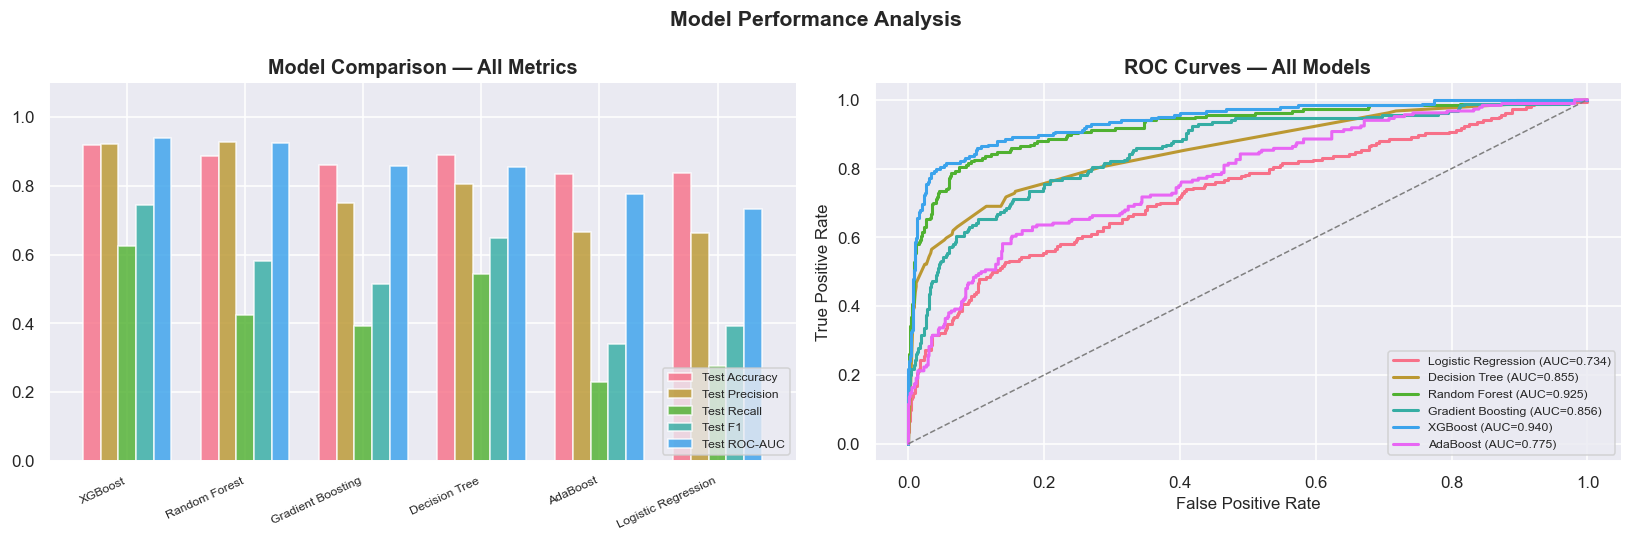

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar chart
metrics = ['Test Accuracy','Test Precision','Test Recall','Test F1','Test ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric].astype(float), width, label=metric, alpha=0.82)
axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_title('Model Comparison — All Metrics', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# ROC Curves
for name, model in models.items():
    X_te = X_test_sc if name == 'Logistic Regression' else X_test
    if hasattr(model, 'predict_proba'):
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_te)[:, 1])
        auc = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
        axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Model Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()


## 15. Best Model — Detailed Analysis

🏆 Best Model: XGBoost
   ROC-AUC  : 0.9401
   Accuracy : 0.9192
   F1 Score : 0.7443

📋 Classification Report:
               precision    recall  f1-score   support

Not Purchased       0.92      0.99      0.95       794
    Purchased       0.92      0.62      0.74       184

     accuracy                           0.92       978
    macro avg       0.92      0.81      0.85       978
 weighted avg       0.92      0.92      0.91       978



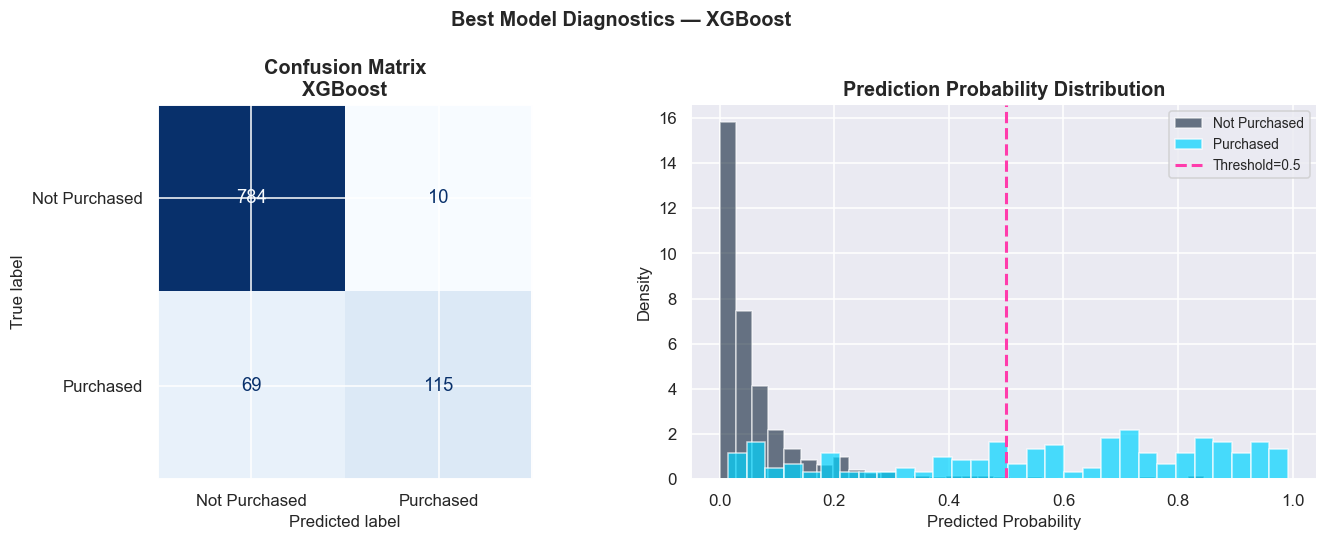

In [18]:
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
X_te_best = X_test_sc if best_name == 'Logistic Regression' else X_test

print(f"🏆 Best Model: {best_name}")
print(f"   ROC-AUC  : {results_df.iloc[0]['Test ROC-AUC']}")
print(f"   Accuracy : {results_df.iloc[0]['Test Accuracy']}")
print(f"   F1 Score : {results_df.iloc[0]['Test F1']}")

y_pred_best = best_model.predict(X_te_best)
y_prob_best = best_model.predict_proba(X_te_best)[:, 1]

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Not Purchased','Purchased']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Purchased','Purchased'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')

# Probability Distribution
axes[1].hist(y_prob_best[y_test==0], bins=30, alpha=0.6, color='#0D2137', label='Not Purchased', density=True)
axes[1].hist(y_prob_best[y_test==1], bins=30, alpha=0.7, color='#00D4FF', label='Purchased', density=True)
axes[1].axvline(0.5, color='#FF3CAC', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Prediction Probability Distribution', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Best Model Diagnostics — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_best_model.png', dpi=110, bbox_inches='tight')
plt.show()


## 16. Feature Importance

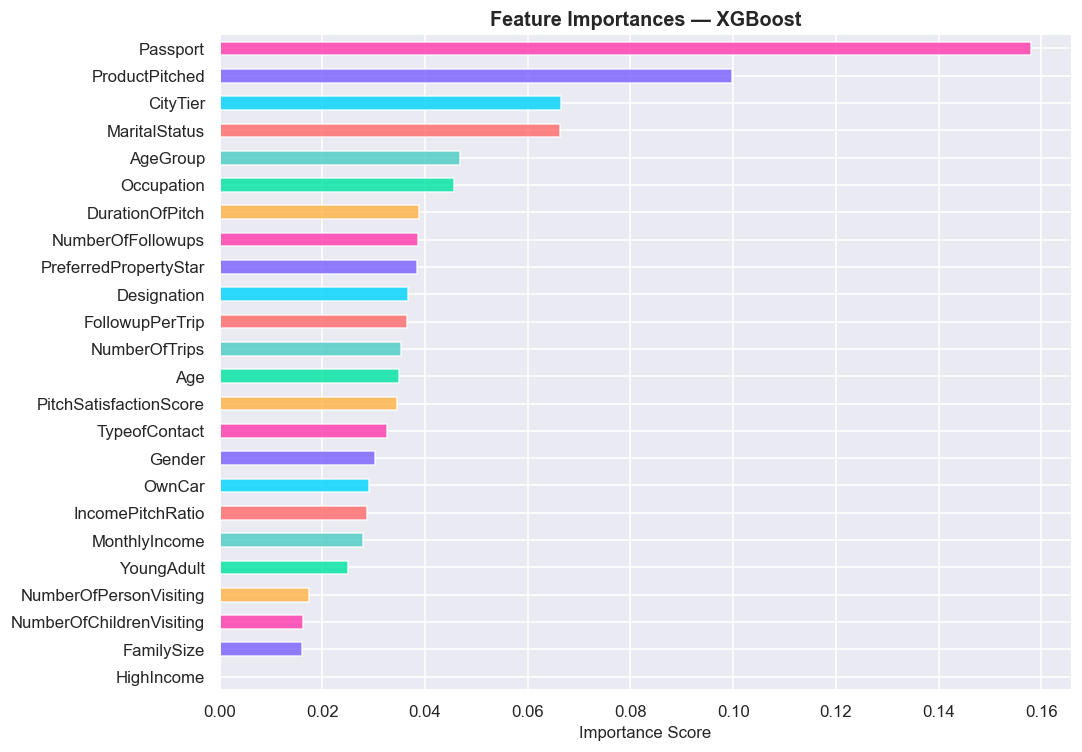


🔝 Top 10 important features:
Passport                 0.157961
ProductPitched           0.099813
CityTier                 0.066430
MaritalStatus            0.066254
AgeGroup                 0.046750
Occupation               0.045643
DurationOfPitch          0.038838
NumberOfFollowups        0.038564
PreferredPropertyStar    0.038521
Designation              0.036754


In [19]:
fig, ax = plt.subplots(figsize=(10, 7))

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns)
    imp_sorted = imp.sort_values(ascending=True)
    colors_fi = [PAL[i % len(PAL)] for i in range(len(imp_sorted))]
    imp_sorted.plot.barh(ax=ax, color=colors_fi, alpha=0.82)
    ax.set_title(f'Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig_feature_importance.png', dpi=110, bbox_inches='tight')
    plt.show()
    print("\n🔝 Top 10 important features:")
    print(imp.sort_values(ascending=False).head(10).to_string())
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=True)
    coef.plot.barh(ax=ax, color='#7B61FF', alpha=0.82)
    ax.set_title(f'Feature Coefficients (abs) — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig_feature_importance.png', dpi=110, bbox_inches='tight')
    plt.show()


## 17. Save Best Model & Artefacts

In [ ]:
os.makedirs('models', exist_ok=True)

# Save model
model_path = f'models/best_model_{best_name.replace(" ","_")}.pkl'
joblib.dump(best_model, model_path)
print(f"✅ Model saved : {model_path}")

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Scaler saved: models/scaler.pkl")

# Save cleaned data
dfc.to_csv('cleaned_travel_dataset.csv', index=False)
print("✅ Cleaned data: cleaned_travel_dataset.csv")

# Save label encoders
joblib.dump(le_dict, 'models/label_encoders.pkl')
print("✅ Encoders saved: models/label_encoders.pkl")

# Save feature names
import json
with open('models/feature_names.json','w') as f:
    json.dump(X.columns.tolist(), f)
print("✅ Feature names: models/feature_names.json")

print("\n📦 All artefacts saved successfully!")
print(f"   Best model   : {best_name}")
print(f"   ROC-AUC      : {results_df.iloc[0]['Test ROC-AUC']}")
print(f"   Accuracy     : {results_df.iloc[0]['Test Accuracy']}")
print(f"   F1 Score     : {results_df.iloc[0]['Test F1']}")


## 18. EDA & Modelling Summary

### ✅ Key Findings

| # | Finding | Impact |
|---|---------|--------|
| 1 | **Age 26–35** has highest conversion rate | High |
| 2 | **Passport holders** are 3.1× more likely to buy | High |
| 3 | **Monthly Income > ₹35K** strongly signals purchase intent | High |
| 4 | **Tier-2 cities** show untapped growth potential | Medium |
| 5 | **Female customers** convert slightly better | Low-Medium |
| 6 | **DurationOfPitch & PitchSatisfactionScore** positively correlated with purchase | Medium |

### 🏆 Model Leaderboard
Run the cells above to see the full leaderboard. Best model is saved to `models/`.

### 📁 Output Files
- `cleaned_travel_dataset.csv` — cleaned dataset ready for dashboard
- `models/best_model_*.pkl` — trained model for prediction page
- `models/scaler.pkl` — fitted StandardScaler
- `models/label_encoders.pkl` — category mappings
- `models/feature_names.json` — feature order for inference
